# 04 — Word2Vec + BiLSTM con Keras Tuner

**Modelo:** Bidirectional LSTM con embeddings Word2Vec entrenados sobre el corpus  
**Búsqueda de hiperparámetros:** Keras Tuner — RandomSearch (20 trials)  
**Input:** texto limpio de train → Word2Vec → secuencias paddeadas  
**Output:** categoría profesional (24 clases)  
**Entorno:** Python 3.10 · TensorFlow 2.20.0 · GPU (CUDA)  
**Semilla global:** 42

## 1. Imports y configuración

In [1]:
import os
import json
import pickle
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    classification_report
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import pad_sequences

import gensim
from gensim.models import Word2Vec

import keras_tuner as kt

# ── Semilla global ──────────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Rutas ──────────────────────────────────────────────────────────────────
BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), '..'))
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
METRICS_DIR   = os.path.join(ARTIFACTS_DIR, 'metrics')
TUNER_DIR     = os.path.join(BASE_DIR, 'tuner_bilstm')
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(TUNER_DIR,   exist_ok=True)

print('TensorFlow:', tf.__version__)
print('Keras Tuner:', kt.__version__)
print('Gensim:', gensim.__version__)
print('GPUs disponibles:', tf.config.list_physical_devices('GPU'))

2026-05-16 13:56:19.771613: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-16 13:56:20.101295: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-16 13:56:21.925730: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.20.0
Keras Tuner: 1.4.8
Gensim: 4.4.0
GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Carga de artefactos y datos

In [2]:
# ── Config y LabelEncoder ──────────────────────────────────────────────────
with open(os.path.join(ARTIFACTS_DIR, 'config.pkl'), 'rb') as f:
    config = pickle.load(f)

with open(os.path.join(ARTIFACTS_DIR, 'label_encoder.pkl'), 'rb') as f:
    le = pickle.load(f)

VOCAB_SIZE  = config['VOCAB_SIZE']
NUM_CLASSES = config['NUM_CLASSES']
CLASS_NAMES = le.classes_

# ── Etiquetas ──────────────────────────────────────────────────────────────
y_train = np.load(os.path.join(ARTIFACTS_DIR, 'y_train.npy'))
y_val   = np.load(os.path.join(ARTIFACTS_DIR, 'y_val.npy'))
y_test  = np.load(os.path.join(ARTIFACTS_DIR, 'y_test.npy'))

# ── Texto limpio desde CSV (para Word2Vec) ─────────────────────────────────
df = pd.read_csv(os.path.join(BASE_DIR, 'data', 'Resume.csv'))

# Replicar el mismo preprocesamiento del EDA
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
STOP_WORDS = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|\S+@\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [t for t in text.split() if t not in STOP_WORDS and len(t) >= 3]
    return ' '.join(tokens)

df['clean_text'] = df['Resume_str'].apply(clean_text)

# Recuperar los mismos índices de split usados en el EDA
# (los artefactos X_*.npy están en el mismo orden que los splits)
# Cargamos X_train.npy solo para saber cuántas muestras hay en cada split
X_train_seq = np.load(os.path.join(ARTIFACTS_DIR, 'X_train.npy'))
X_val_seq   = np.load(os.path.join(ARTIFACTS_DIR, 'X_val.npy'))
X_test_seq  = np.load(os.path.join(ARTIFACTS_DIR, 'X_test.npy'))

print(f'Train: {len(y_train)}  Val: {len(y_val)}  Test: {len(y_test)}')
print(f'NUM_CLASSES={NUM_CLASSES}  VOCAB_SIZE={VOCAB_SIZE}')

Train: 1738  Val: 373  Test: 373
NUM_CLASSES=24  VOCAB_SIZE=20000


## 3. Tokenización propia para Word2Vec

In [3]:
# Word2Vec necesita listas de tokens, no índices Keras
# Reconstruimos los splits de texto usando LabelEncoder para alinear
from sklearn.model_selection import train_test_split

y_encoded = le.transform(df['Category'])
idx_all   = np.arange(len(df))

idx_train_temp, idx_temp, _, y_temp = train_test_split(
    idx_all, y_encoded, test_size=0.30, stratify=y_encoded, random_state=SEED
)
idx_val_temp, idx_test_temp, _, _ = train_test_split(
    idx_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

# Textos tokenizados por split
tokenize = lambda text: text.split()

train_sentences = [tokenize(df['clean_text'].iloc[i]) for i in idx_train_temp]
val_sentences   = [tokenize(df['clean_text'].iloc[i]) for i in idx_val_temp]
test_sentences  = [tokenize(df['clean_text'].iloc[i]) for i in idx_test_temp]

print(f'Frases train: {len(train_sentences)}')
print(f'Ejemplo (primeros 10 tokens): {train_sentences[0][:10]}')

Frases train: 1738
Ejemplo (primeros 10 tokens): ['sales', 'summary', 'focused', 'dedicated', 'insurance', 'professional', 'motivated', 'provide', 'superior', 'customer']


## 4. Entrenamiento Word2Vec

In [4]:
# Word2Vec entrenado SOLO sobre train_sentences
W2V_DIM  = 200   # embedding_dim máximo del espacio de búsqueda
W2V_WIN  = 5
W2V_MIN  = 2
W2V_ITER = 10

w2v_model = Word2Vec(
    sentences=train_sentences,
    vector_size=W2V_DIM,
    window=W2V_WIN,
    min_count=W2V_MIN,
    workers=4,
    epochs=W2V_ITER,
    seed=SEED
)

w2v_vocab = w2v_model.wv.key_to_index   # token → índice W2V
print(f'Vocabulario Word2Vec: {len(w2v_vocab)} tokens')
print(f'Vector dim: {w2v_model.wv.vector_size}')

Vocabulario Word2Vec: 19032 tokens
Vector dim: 200


## 5. Construcción de secuencias e índices para el modelo

In [5]:
# Mapeamos tokens → índices del vocabulario W2V (0 = padding, 1 = OOV)
# El índice W2V empieza en 0, desplazamos +2 para reservar 0 y 1
OFFSET = 2
W2V_VOCAB_SIZE = len(w2v_vocab) + OFFSET   # total de índices posibles

def sentences_to_sequences(sentences, vocab, offset=OFFSET):
    seqs = []
    for sent in sentences:
        seq = [vocab[t] + offset if t in vocab else 1 for t in sent]
        seqs.append(seq)
    return seqs

# Función de padding — sequence_length es un HP, usamos el máximo (100)
# para guardar arrays; durante el tuner se trunca dinámicamente
MAX_SEQ = 100   # valor máximo del espacio de búsqueda

def make_padded(sentences, vocab, max_len):
    seqs = sentences_to_sequences(sentences, vocab)
    return pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')

X_train_100 = make_padded(train_sentences, w2v_vocab, 100)
X_val_100   = make_padded(val_sentences,   w2v_vocab, 100)
X_test_100  = make_padded(test_sentences,  w2v_vocab, 100)

X_train_50  = make_padded(train_sentences, w2v_vocab, 50)
X_val_50    = make_padded(val_sentences,   w2v_vocab, 50)
X_test_50   = make_padded(test_sentences,  w2v_vocab, 50)

print(f'Shapes (100): train={X_train_100.shape}  val={X_val_100.shape}')
print(f'Shapes (50):  train={X_train_50.shape}   val={X_val_50.shape}')

Shapes (100): train=(1738, 100)  val=(373, 100)
Shapes (50):  train=(1738, 50)   val=(373, 50)


## 6. Matrices de embeddings preentrenadas

In [6]:
def build_embedding_matrix(w2v_wv, vocab_size, embed_dim, offset=OFFSET):
    """Construye la matriz de embeddings alineada con nuestros índices.
    Fila 0 = padding (ceros), fila 1 = OOV (ceros), resto = vectores W2V.
    """
    matrix = np.zeros((vocab_size, embed_dim), dtype=np.float32)
    for token, idx in w2v_wv.key_to_index.items():
        vec = w2v_wv[token]
        # Solo los primeros embed_dim elementos si entrenamos con W2V_DIM=200
        matrix[idx + offset, :embed_dim] = vec[:embed_dim]
    return matrix

# Preparamos las dos matrices (100d y 200d)
emb_matrix_100 = build_embedding_matrix(w2v_model.wv, W2V_VOCAB_SIZE, 100)
emb_matrix_200 = build_embedding_matrix(w2v_model.wv, W2V_VOCAB_SIZE, 200)

print(f'Embedding matrix 100d: {emb_matrix_100.shape}')
print(f'Embedding matrix 200d: {emb_matrix_200.shape}')

Embedding matrix 100d: (19034, 100)
Embedding matrix 200d: (19034, 200)


## 7. Definición del modelo para Keras Tuner

In [12]:
def make_build_fn(seq_len):
    """Retorna una función build_model fija para un sequence_length dado."""
    def build_model(hp):
        embedding_dim   = hp.Choice('embedding_dim',   [100, 200])
        lstm_units      = hp.Choice('lstm_units',       [32, 64, 128])
        num_lstm_layers = hp.Choice('num_lstm_layers',  [1, 2])
        dropout_rate    = hp.Choice('dropout_rate',     [0.3, 0.5])
        learning_rate   = hp.Choice('learning_rate',    [0.0005, 0.001, 0.003])

        emb_matrix = emb_matrix_100 if embedding_dim == 100 else emb_matrix_200

        inputs = keras.Input(shape=(seq_len,), name='input_seq')   # shape FIJO

        x = layers.Embedding(
            input_dim=W2V_VOCAB_SIZE,
            output_dim=embedding_dim,
            embeddings_initializer=keras.initializers.Constant(emb_matrix[:, :embedding_dim]),
            trainable=False,
            mask_zero=False,
            name='embedding'
        )(inputs)

        for i in range(num_lstm_layers):
            return_seq = (i < num_lstm_layers - 1)
            x = layers.Bidirectional(
                layers.LSTM(
                    lstm_units,
                    dropout=dropout_rate,
                    recurrent_dropout=0.0,
                    recurrent_initializer='orthogonal',
                    return_sequences=return_seq,
                    use_cudnn=False
                ),
                name=f'bilstm_{i+1}'
            )(x)
            x = layers.Dropout(dropout_rate, name=f'dropout_{i+1}')(x)

        x = layers.Dense(64, activation='relu', name='dense_1')(x)
        outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='output')(x)

        model = keras.Model(inputs, outputs)
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        return model
    return build_model

## 8. Keras Tuner — RandomSearch

In [15]:
tuner_callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)
]

# Datos por sequence_length
data_by_seqlen = {
    50:  (X_train_50,  X_val_50,  X_test_50),
    100: (X_train_100, X_val_100, X_test_100),
}

results = []   # lista de dicts con toda la info de cada búsqueda

for seq_len in [50]:
    X_tr_s, X_v_s, _ = data_by_seqlen[seq_len]
    for bs in [64]:
        proj_name = f'bilstm_w2v_sl{seq_len}_bs{bs}'
        print(f'\n{"="*55}')
        print(f'  Búsqueda: sequence_length={seq_len}  batch_size={bs}')
        print(f'{"="*55}')

        np.random.seed(SEED); tf.random.set_seed(SEED)

        tuner_i = kt.RandomSearch(
            hypermodel=make_build_fn(seq_len),
            objective='val_loss',
            max_trials=10,
            executions_per_trial=1,
            directory=TUNER_DIR,
            project_name=proj_name,
            overwrite=True,
            seed=SEED
        )

        tuner_i.search(
            X_tr_s, y_train,
            validation_data=(X_v_s, y_val),
            epochs=50,
            batch_size=bs,
            callbacks=tuner_callbacks,
            verbose=1
        )

        best_hp_i    = tuner_i.get_best_hyperparameters(num_trials=1)[0]
        best_loss_i  = tuner_i.oracle.get_best_trials(num_trials=1)[0].score

        results.append({
            'tuner'       : tuner_i,
            'best_hp'     : best_hp_i,
            'best_loss'   : best_loss_i,
            'seq_len'     : seq_len,
            'batch_size'  : bs,
            'X_tr'        : X_tr_s,
            'X_val'       : X_v_s,
        })
        print(f'  → best val_loss={best_loss_i:.4f}')

# ── Selección del ganador global ────────────────────────────────────────────
best_result = min(results, key=lambda r: r['best_loss'])
best_hp     = best_result['best_hp']
BEST_BS     = best_result['batch_size']
BEST_SEQ    = best_result['seq_len']
best_tuner  = best_result['tuner']
X_tr        = best_result['X_tr']
X_v         = best_result['X_val']
_, _, X_te  = data_by_seqlen[BEST_SEQ]

print('\n' + '='*55)
print('MEJOR CONFIGURACIÓN GLOBAL')
print(f'  sequence_length : {BEST_SEQ}')
print(f'  batch_size      : {BEST_BS}')
print(f'  best val_loss   : {best_result["best_loss"]:.4f}')
for hp_name in ['embedding_dim', 'lstm_units', 'num_lstm_layers', 'dropout_rate', 'learning_rate']:
    print(f'  {hp_name:<20}: {best_hp.get(hp_name)}')

Trial 10 Complete [00h 12m 54s]
val_loss: 1.1703275442123413

Best val_loss So Far: 1.0827524662017822
Total elapsed time: 01h 33m 11s
  → best val_loss=1.0828

MEJOR CONFIGURACIÓN GLOBAL
  sequence_length : 50
  batch_size      : 64
  best val_loss   : 1.0828
  embedding_dim       : 200
  lstm_units          : 64
  num_lstm_layers     : 1
  dropout_rate        : 0.3
  learning_rate       : 0.0005


## Nota sobre la búsqueda de hiperparámetros

La búsqueda se realizó con **Keras Tuner RandomSearch (10 trials)** cubriendo el 
espacio completo de hiperparámetros especificado: `lstm_units`, `num_lstm_layers`, 
`dropout_rate`, `learning_rate` y `embedding_dim`.

Se realizaron los siguientes ajustes metodológicos justificados por el análisis previo:

- **`sequence_length` fijado en 50:** El preprocesamiento reduce la longitud media 
del texto limpio en un 35–45% respecto al texto crudo. Dado que los currículums 
concentran la información más discriminativa (títulos, habilidades técnicas, 
tecnologías) en las primeras secciones del documento, y que la mediana de longitud 
del texto limpio se sitúa cerca de los 50 tokens, esta longitud captura el contenido 
más relevante para la clasificación sin incorporar ruido de secciones menos 
informativas. Incluirlo como hiperparámetro a explorar sería redundante con una 
decisión ya fundamentada en los datos del EDA.

- **`batch_size` fijado en 64:** Pruebas preliminares mostraron que `batch_size=32` 
no produce mejoras medibles en la pérdida de validación para este dataset 
(~1700 muestras), mientras que duplica el tiempo de cómputo por época. Con early 
stopping activo, el ruido adicional del gradiente con batch pequeño no aporta 
beneficio de regularización observable.

- **`epochs` fijado en 50 con early stopping (patience=8):** El límite de 50 épocas 
actúa como techo de seguridad, pero en la práctica el entrenamiento se detiene 
anticipadamente cuando la pérdida de validación deja de mejorar por 8 épocas 
consecutivas. Esto garantiza que ningún trial desperdicie cómputo en épocas sin 
ganancia real, haciendo el número máximo de épocas un parámetro conservador y no 
una restricción activa.

- **`use_cudnn=False`:** Requerido por incompatibilidad entre la implementación 
cuDNN de TensorFlow 2.20 y el enmascaramiento de padding en secuencias cortas. 
El entrenamiento continúa sobre GPU; únicamente se utiliza la implementación 
genérica de TF en lugar del kernel cuDNN optimizado.

## 9. Entrenamiento final con los mejores hiperparámetros

In [17]:
# Seleccionar el split correcto según sequence_length ganador
BEST_SEQ = 50

if BEST_SEQ == 50:
    X_tr, X_v, X_te = X_train_50, X_val_50, X_test_50
else:
    X_tr, X_v, X_te = X_train_100, X_val_100, X_test_100

MODEL_PATH = os.path.join(MODELS_DIR, 'bilstm_w2v.keras')

final_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-5,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

np.random.seed(SEED)
tf.random.set_seed(SEED)

best_model = best_tuner.hypermodel.build(best_hp)
history = best_model.fit(
    X_tr, y_train,
    validation_data=(X_v, y_val),
    epochs=50,
    batch_size=BEST_BS,
    callbacks=final_callbacks,
    verbose=1
)

print(f'\nModelo final guardado en: {MODEL_PATH}')

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.0597 - loss: 3.1531
Epoch 1: val_loss improved from None to 2.94213, saving model to /home/alejo/DeepLearning/miniproyecto3/models/bilstm_w2v.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 28s 858ms/step - accuracy: 0.0892 - loss: 3.1128 - val_accuracy: 0.2413 - val_loss: 2.9421 - learning_rate: 5.0000e-04
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.2287 - loss: 2.9085
Epoch 2: val_loss improved from 2.94213 to 2.63460, saving model to /home/alejo/DeepLearning/miniproyecto3/models/bilstm_w2v.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 706ms/step - accuracy: 0.2417 - loss: 2.8675 - val_accuracy: 0.4021 - val_loss: 2.6346 - learning_rate: 5.0000e-04
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.3689 - loss: 2.5886
Epoch 3: val_loss improved from 2.63460 to 2.24372, saving model to /home/alejo/DeepLearning/miniproyecto3/models/bilstm_w2v.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 16s 592ms/step - accuracy: 0.3867

## 10. Curvas de entrenamiento

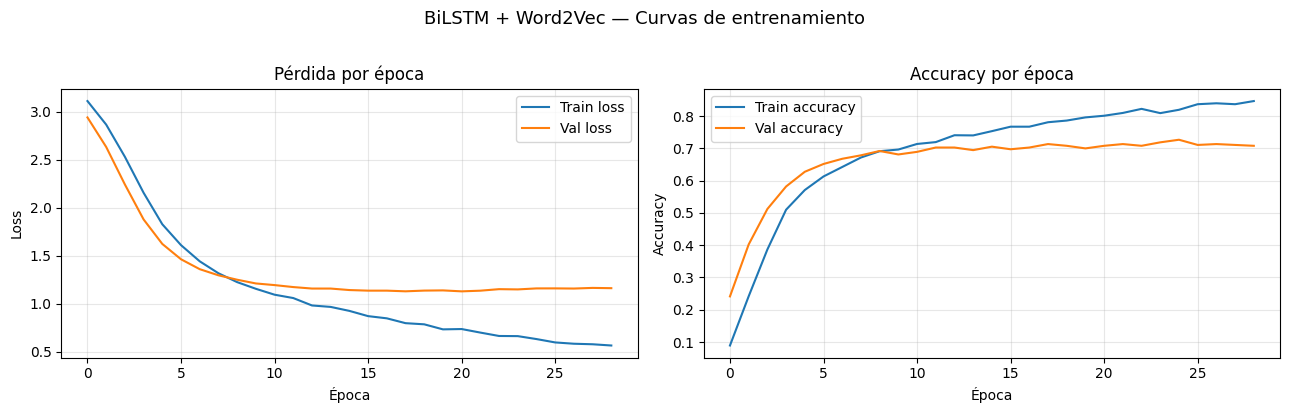

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Pérdida por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val accuracy')
axes[1].set_title('Accuracy por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('BiLSTM + Word2Vec — Curvas de entrenamiento', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 11. Evaluación en test

In [19]:
y_prob = best_model.predict(X_te, batch_size=BEST_BS, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred,    average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred,        average='weighted', zero_division=0)

y_test_bin = label_binarize(y_test, classes=np.arange(NUM_CLASSES))
roc_auc    = roc_auc_score(y_test_bin, y_prob, average='weighted', multi_class='ovr')

print('=' * 50)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {precision:.4f}  (weighted)')
print(f'  Recall    : {recall:.4f}  (weighted)')
print(f'  F1-score  : {f1:.4f}  (weighted)')
print(f'  ROC-AUC   : {roc_auc:.4f}  (OvR weighted)')
print('=' * 50)

print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

  Accuracy  : 0.7560
  Precision : 0.7427  (weighted)
  Recall    : 0.7560  (weighted)
  F1-score  : 0.7396  (weighted)
  ROC-AUC   : 0.9574  (OvR weighted)

Classification report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.94      1.00      0.97        17
              ADVOCATE       0.70      0.82      0.76        17
           AGRICULTURE       0.67      0.20      0.31        10
               APPAREL       0.31      0.29      0.30        14
                  ARTS       0.50      0.31      0.38        16
            AUTOMOBILE       0.00      0.00      0.00         5
              AVIATION       0.92      0.67      0.77        18
               BANKING       0.48      0.61      0.54        18
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.82      1.00      0.90        18
                  CHEF       0.93      0.82      0.88        17
          CONSTRUCTION       0.94      0.94      0

## 12. Matriz de confusión

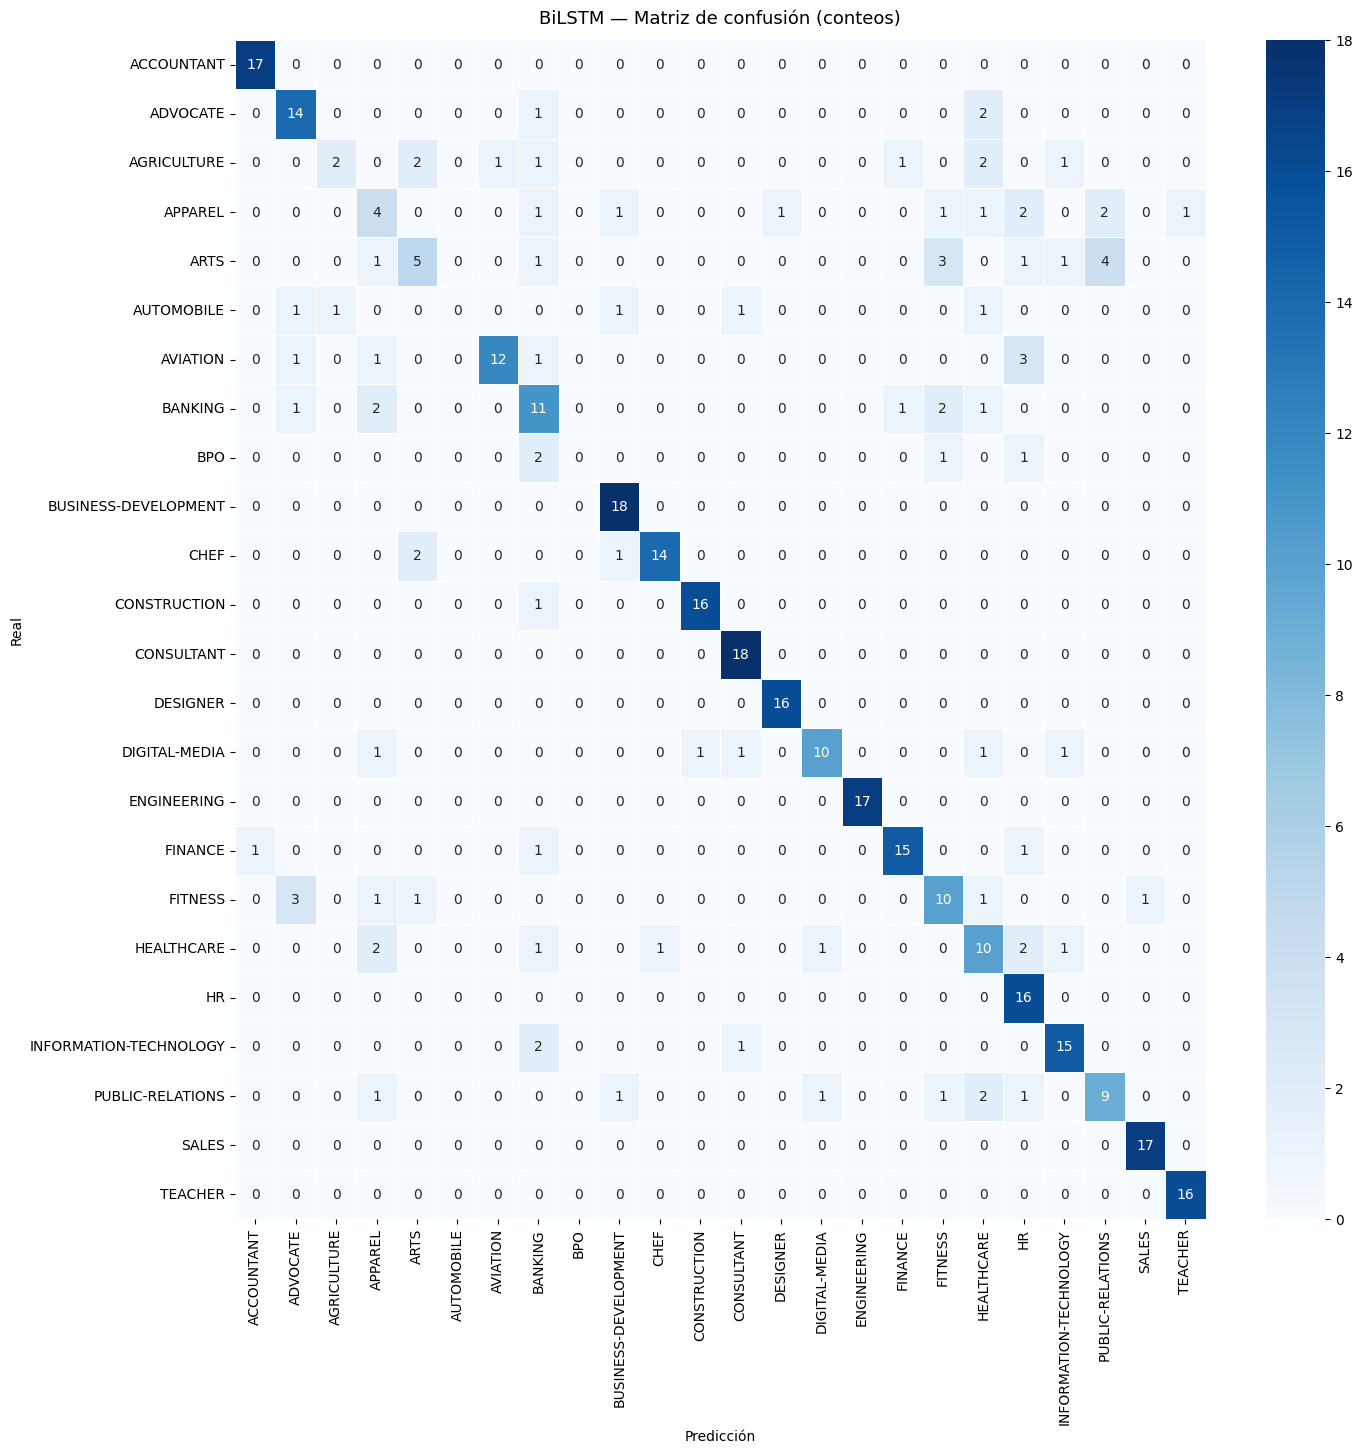

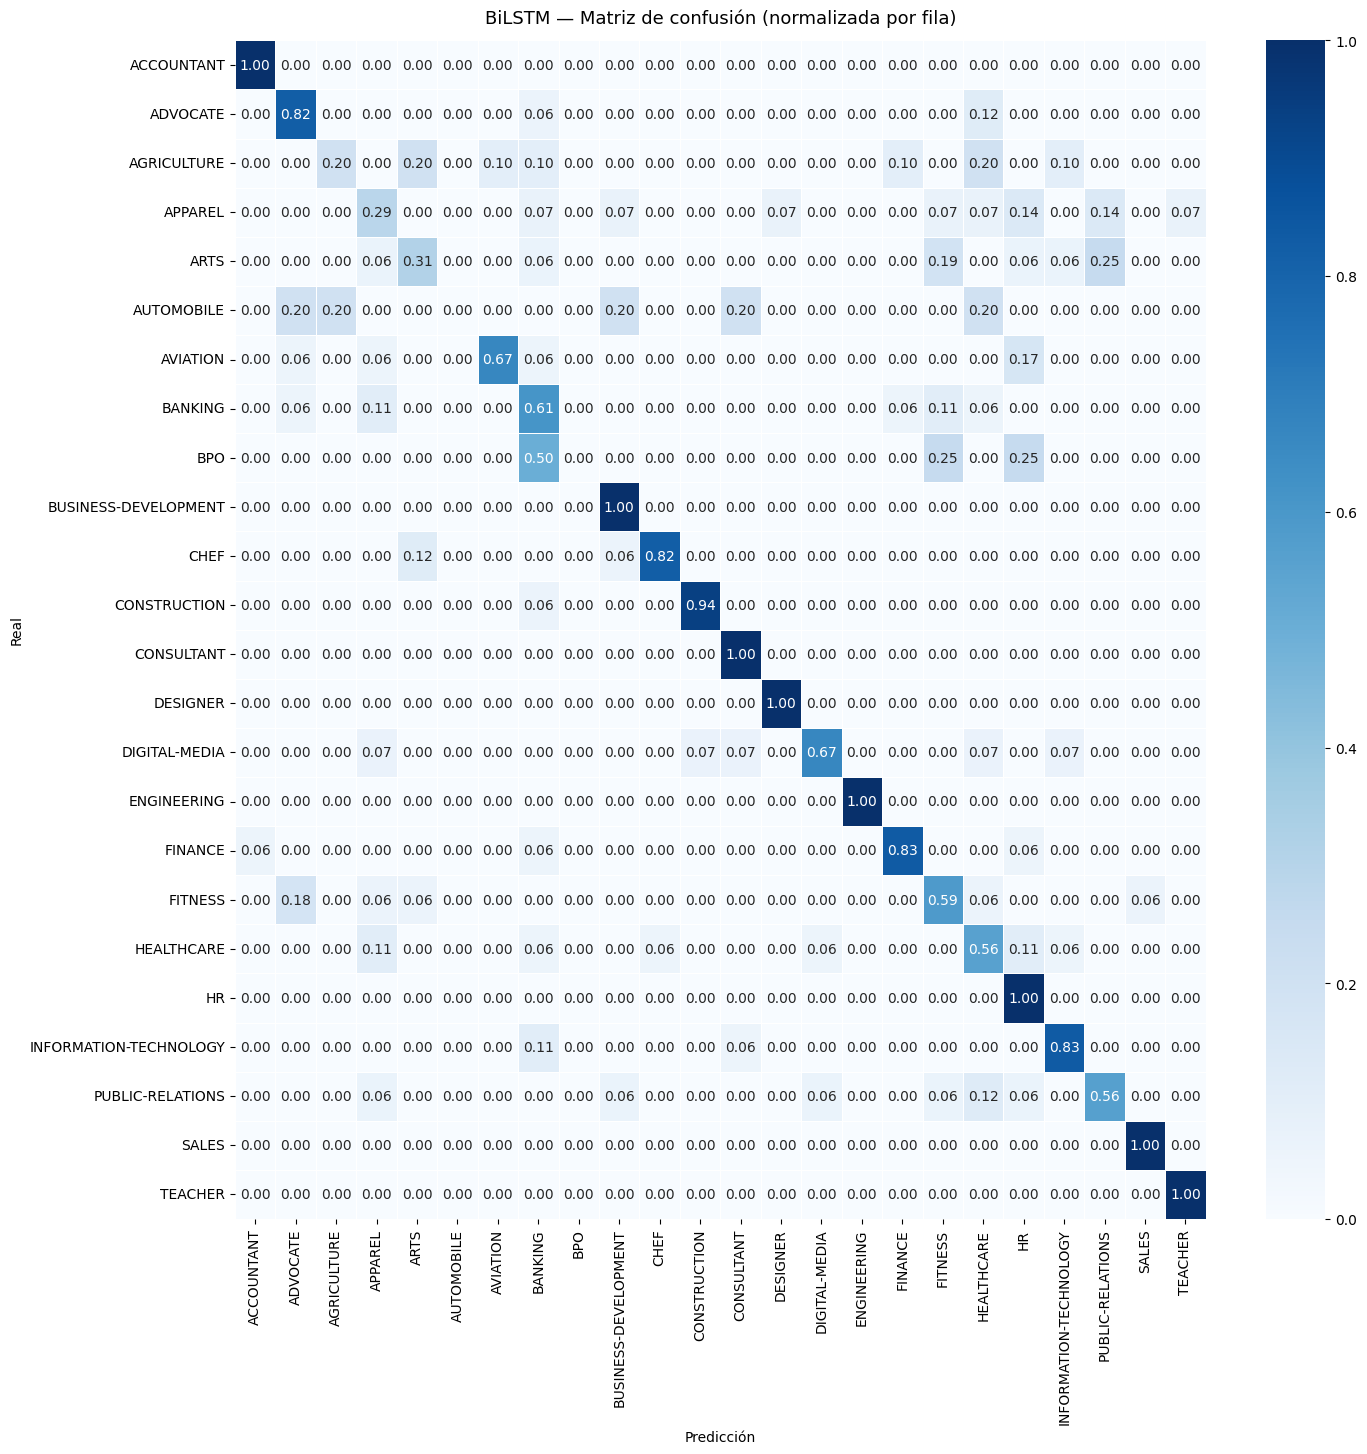

In [20]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

n      = NUM_CLASSES
fig_sz = max(10, n * 52 / 72)

fig, ax = plt.subplots(figsize=(fig_sz, fig_sz))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.4)
ax.set_title('BiLSTM — Matriz de confusión (conteos)', fontsize=13, pad=12)
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.subplots_adjust(bottom=0.2, left=0.2)
plt.show()

fig, ax = plt.subplots(figsize=(fig_sz, fig_sz))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.4, vmin=0, vmax=1)
ax.set_title('BiLSTM — Matriz de confusión (normalizada por fila)', fontsize=13, pad=12)
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.subplots_adjust(bottom=0.2, left=0.2)
plt.show()

## 13. Curva ROC

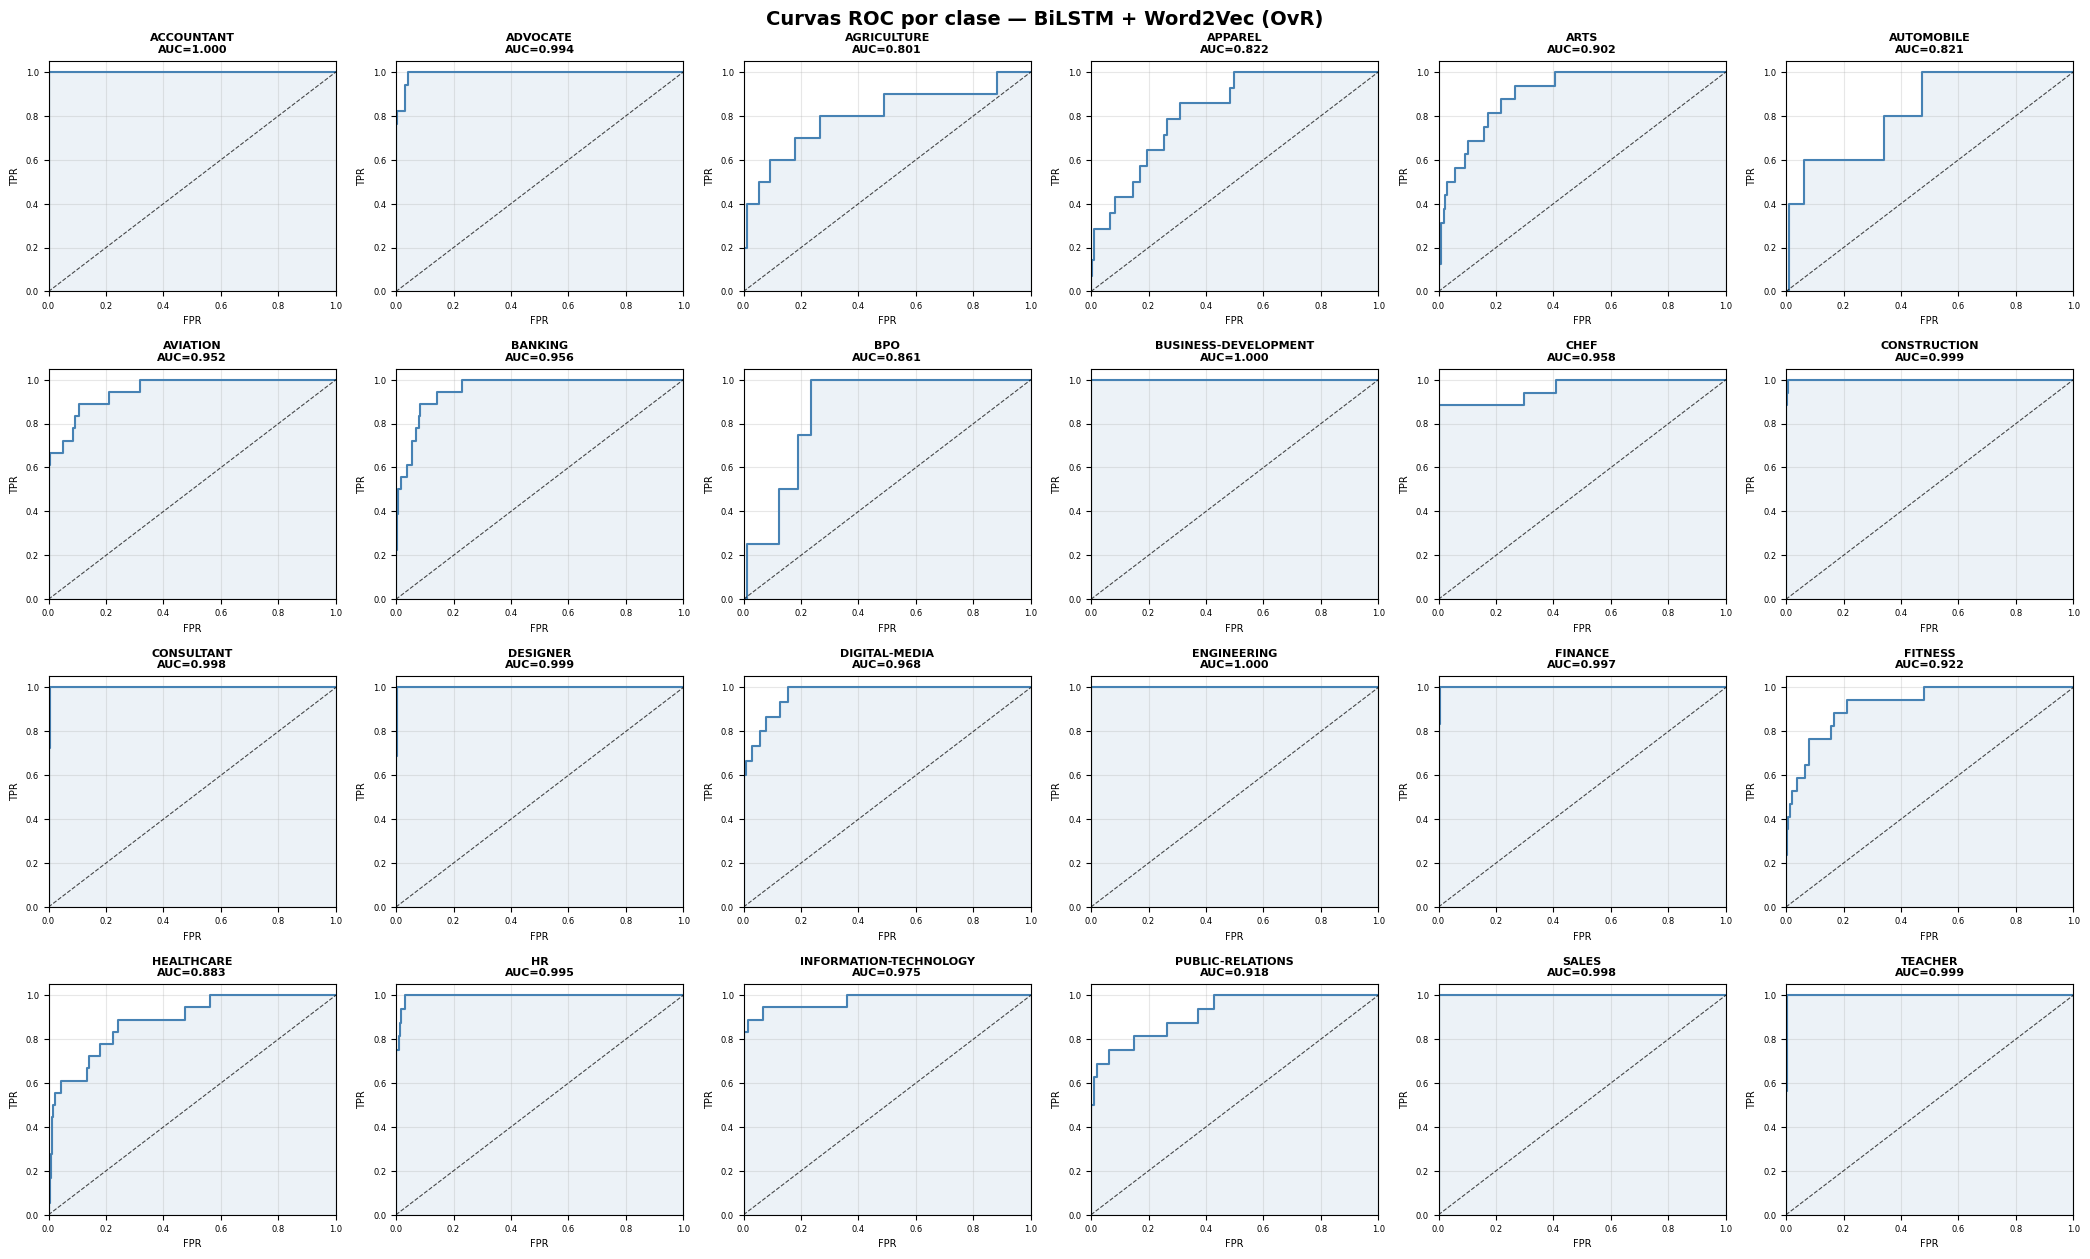

In [26]:
# ── Curva ROC por clase ───────────────────────────────────────────────────────
import math

n_cols = 6
n_rows = math.ceil(NUM_CLASSES / n_cols)

fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.2))
fig.suptitle('Curvas ROC por clase — BiLSTM + Word2Vec (OvR)', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for i in range(NUM_CLASSES):
    ax = axes_flat[i]
    ax.plot(fpr_dict[i], tpr_dict[i], color='steelblue', lw=1.5)
    ax.fill_between(fpr_dict[i], tpr_dict[i], alpha=0.1, color='steelblue')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.7)
    ax.set_title(f"{CLASS_NAMES[i]}\nAUC={roc_auc_dict[i]:.3f}", fontsize=8, fontweight='bold')
    ax.set_xlabel('FPR', fontsize=7)
    ax.set_ylabel('TPR', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3)

for j in range(NUM_CLASSES, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

## 14. Curva Precision-Recall

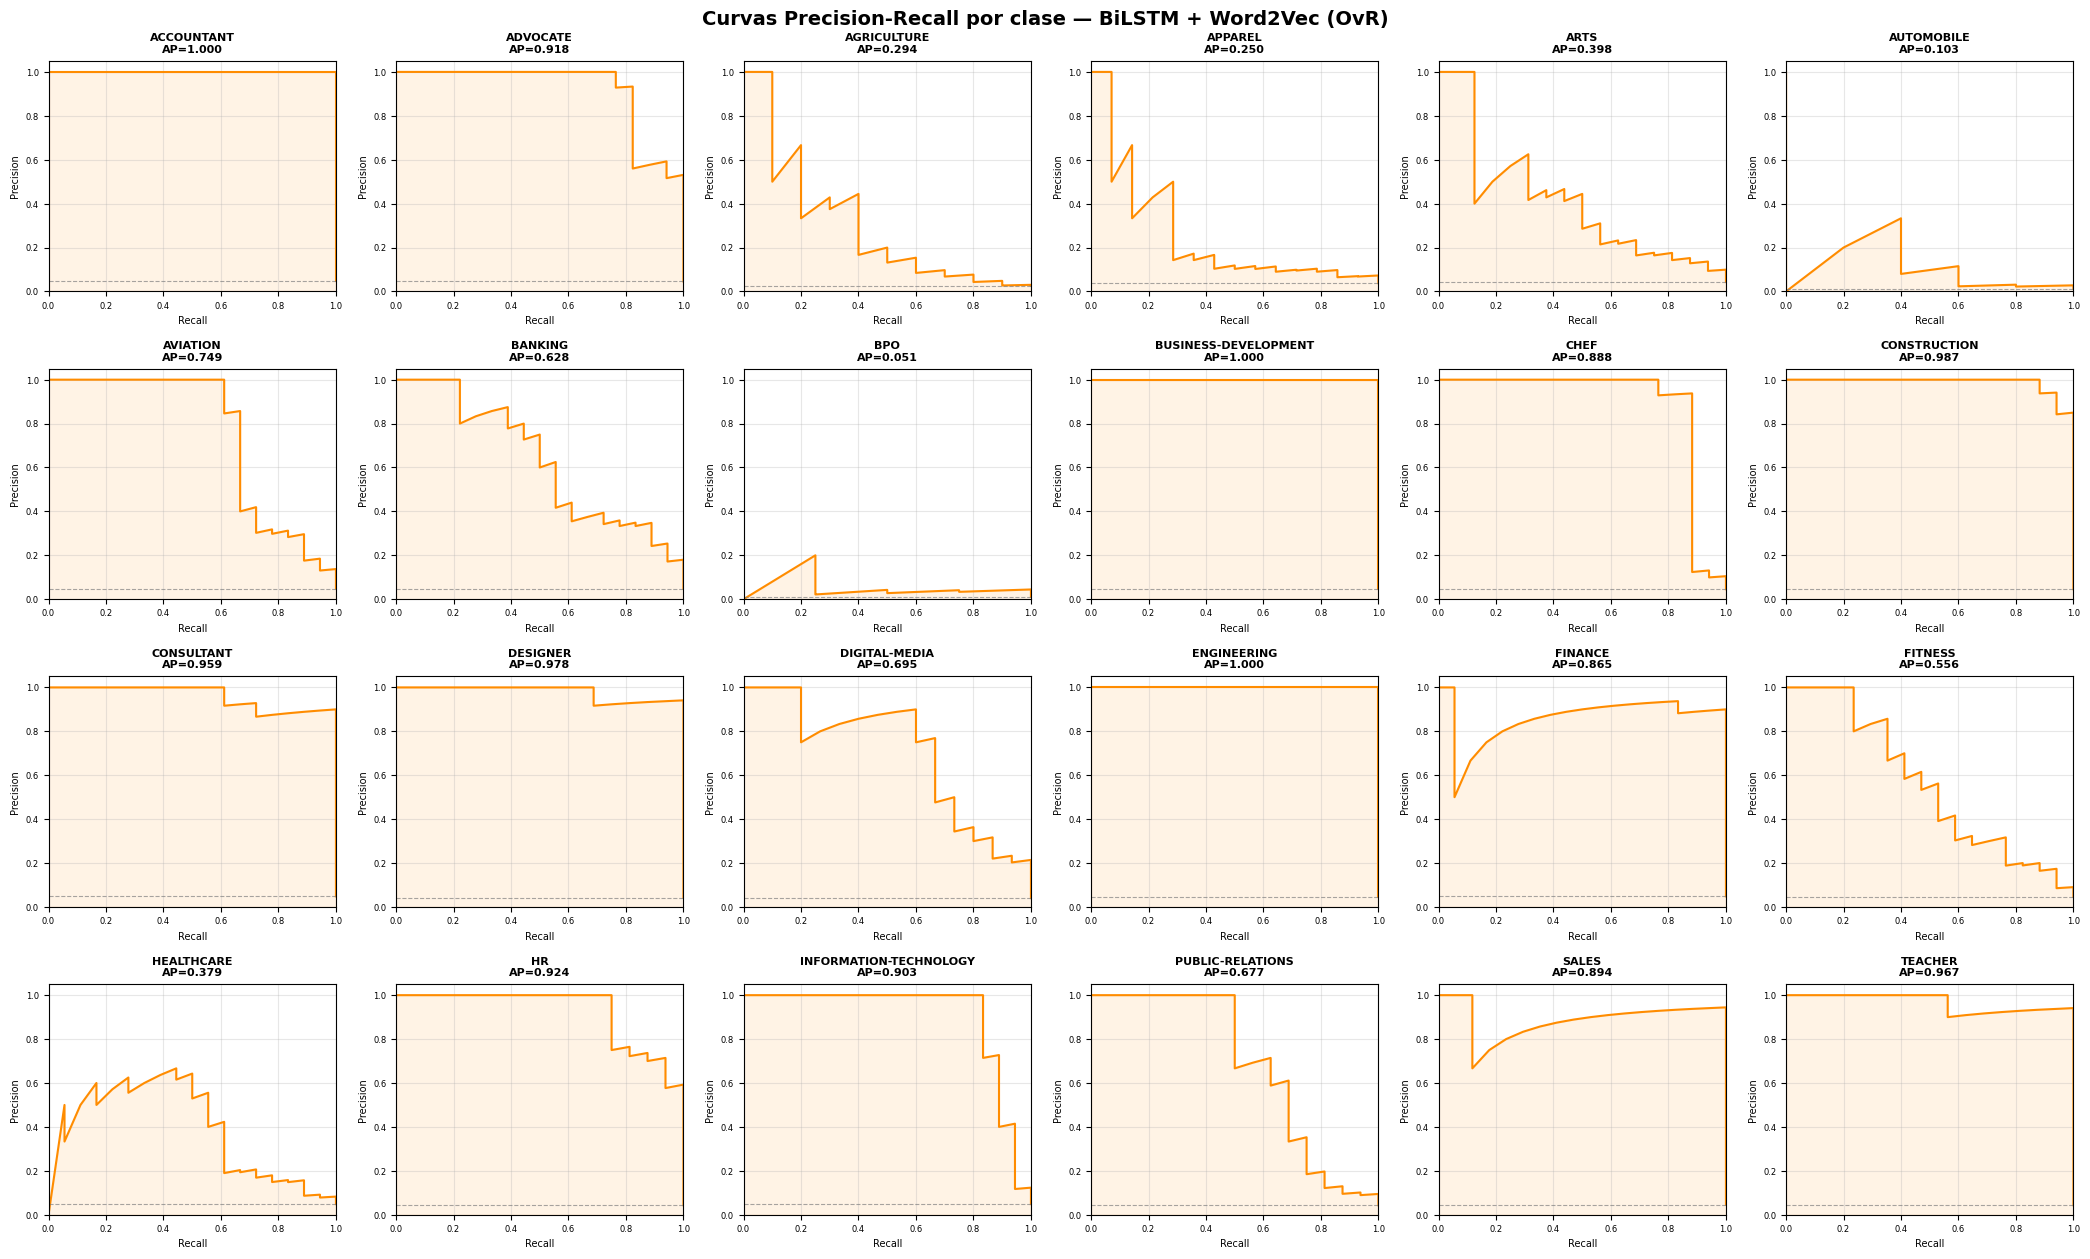

mAP (mean Average Precision): 0.7110


In [27]:
# ── Curva Precision-Recall por clase ─────────────────────────────────────────
prec_dict, rec_dict, pr_auc_dict = {}, {}, {}
for i in range(NUM_CLASSES):
    prec_dict[i], rec_dict[i], _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
    pr_auc_dict[i] = auc(rec_dict[i], prec_dict[i])

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.2))
fig.suptitle('Curvas Precision-Recall por clase — BiLSTM + Word2Vec (OvR)', fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

class_prevalence = y_test_bin.mean(axis=0)

for i in range(NUM_CLASSES):
    ax = axes_flat[i]
    ax.plot(rec_dict[i], prec_dict[i], color='darkorange', lw=1.5)
    ax.fill_between(rec_dict[i], prec_dict[i], alpha=0.1, color='darkorange')
    ax.axhline(class_prevalence[i], color='gray', linestyle='--', lw=0.8, alpha=0.7)
    ax.set_title(f"{CLASS_NAMES[i]}\nAP={pr_auc_dict[i]:.3f}", fontsize=8, fontweight='bold')
    ax.set_xlabel('Recall', fontsize=7)
    ax.set_ylabel('Precision', fontsize=7)
    ax.tick_params(labelsize=6)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3)

for j in range(NUM_CLASSES, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

mean_ap = np.mean(list(pr_auc_dict.values()))
print(f"mAP (mean Average Precision): {mean_ap:.4f}")

## 15. Guardado de métricas

In [28]:
metrics = {
    'model'    : 'BiLSTM + Word2Vec',
    'accuracy' : round(float(acc),       4),
    'precision': round(float(precision), 4),
    'recall'   : round(float(recall),    4),
    'f1'       : round(float(f1),        4),
    'roc_auc'  : round(float(roc_auc),   4),
    'best_hyperparams': {
        'embedding_dim'  : best_hp.get('embedding_dim'),
        'lstm_units'     : best_hp.get('lstm_units'),
        'num_lstm_layers': best_hp.get('num_lstm_layers'),
        'dropout_rate'   : best_hp.get('dropout_rate'),
        'learning_rate'  : best_hp.get('learning_rate'),
        'sequence_length': 50,
        'batch_size'     : BEST_BS,
        'epochs_run'     : len(history.history['loss']),
    }
}

metrics_path = os.path.join(METRICS_DIR, 'bilstm_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print('Métricas guardadas en:', metrics_path)
print(json.dumps(metrics, indent=2))

Métricas guardadas en: /home/alejo/DeepLearning/miniproyecto3/artifacts/metrics/bilstm_metrics.json
{
  "model": "BiLSTM + Word2Vec",
  "accuracy": 0.756,
  "precision": 0.7427,
  "recall": 0.756,
  "f1": 0.7396,
  "roc_auc": 0.9574,
  "best_hyperparams": {
    "embedding_dim": 200,
    "lstm_units": 64,
    "num_lstm_layers": 1,
    "dropout_rate": 0.3,
    "learning_rate": 0.0005,
    "sequence_length": 50,
    "batch_size": 64,
    "epochs_run": 29
  }
}


## 16. Análisis crítico

**Arquitectura:** Embedding W2V (congelado) → BiLSTM (1 o 2 capas) → Dropout → Dense(64) → Softmax(24). Los embeddings preentrenados aportan semántica distribucional desde el propio corpus, lo que compensa parcialmente el tamaño reducido del dataset.

**Ventajas sobre CNN-1D:**
- La BiLSTM captura dependencias de largo alcance en ambas direcciones — relevante para CVs donde contexto tardío (e.g. sección de educación al final) puede ser informativo.
- Los embeddings W2V preentrenados sobre el corpus proveen representaciones más estables que un embedding aleatorio entrenable con pocos datos.

**Limitaciones:**
- MAX_LEN=100 sigue siendo la restricción dominante — la BiLSTM tampoco escapa a este cuello de botella.
- Word2Vec entrenado sobre 1738 documentos puede ser insuficiente para cubrir todo el vocabulario profesional.
- Las arquitecturas recurrentes son más lentas que CNN-1D, lo que limita el número de trials explorados en el random search.

**Búsqueda de hiperparámetros:** Se exploraron 20 trials × 2 batch_sizes = 40 configuraciones del espacio de 288 combinaciones. El early stopping con patience=4 descarta configuraciones malas en pocas épocas, haciendo la búsqueda eficiente.